# CerviGrade — Dataset acquisition (Kaggle)

Kaggle works differently from Colab in a way that fixes the exact problem you kept hitting: **attached input datasets don't live on ephemeral disk and don't re-download every session.** Once you attach a dataset here, it's just instantly there every time you open this notebook again — no Drive quota, no waiting.

**Two of your three datasets already exist as public Kaggle datasets:**
- SIPaKMeD, from the dataset's own author: [kaggle.com/datasets/marinaeplissiti/sipakmed](https://www.kaggle.com/datasets/marinaeplissiti/sipakmed)
- Mendeley LBC (community re-upload, worth double-checking against the original 963/4-class spec once attached): [kaggle.com/datasets/blank1508/mendeley-lbc-cervical-cancer](https://www.kaggle.com/datasets/blank1508/mendeley-lbc-cervical-cancer)

**CRIC has no Kaggle mirror**, so this notebook still downloads it from Figshare directly — same as before, just running here instead of Colab. The plan: download it once, then publish it as your *own* Kaggle dataset from this notebook's output, so future sessions attach it too instead of re-downloading.

## Before running anything
1. **Verify your phone number** on your Kaggle account (Settings → Phone Verification) if you haven't already — Kaggle requires this before it lets a notebook use the internet, and the CRIC cell needs internet access to reach Figshare.
2. In this notebook's right sidebar, click **Add Input**, search "SIPaKMeD", and add the one by **marinaeplissiti** (the link above). Search "Mendeley LBC Cervical Cancer" and add the one by **blank1508**.
3. In the notebook's settings (the "..." menu, or the gear icon in the right sidebar), turn **Internet: On**. Leave the accelerator as **None** — this notebook only downloads files, it doesn't need a GPU (save your weekly GPU quota for the actual training notebooks later).
4. Run the cells below top to bottom.

## Check attached datasets

Kaggle mounts each attached dataset read-only under `/kaggle/input/<name>/`. This just prints what's actually in there — community uploads don't always use the exact folder layout you'd expect, so it's worth looking before writing code against it.

In [2]:
import os

INPUT_ROOT = "/kaggle/input"

def explore(path, prefix=""):
    try:
        entries = sorted(os.listdir(path))
    except PermissionError:
        print(f"{prefix}(can't list this folder)")
        return
    dirs = [e for e in entries if os.path.isdir(os.path.join(path, e))]
    files = [e for e in entries if os.path.isfile(os.path.join(path, e))]
    if files:
        print(f"{prefix}{len(files)} file(s) here, e.g. {files[:3]}")
    for d in dirs:
        print(f"{prefix}{d}/")
        explore(os.path.join(path, d), prefix + "  ")

print("Datasets currently attached to this notebook:")
if not os.path.isdir(INPUT_ROOT) or not os.listdir(INPUT_ROOT):
    print("  none found")
else:
    explore(INPUT_ROOT)

Datasets currently attached to this notebook:
datasets/
  blank1508/
    mendeley-lbc-cervical-cancer/
      High squamous intra-epithelial lesion/
        163 file(s) here, e.g. ['HSIL_1 (1).jpg', 'HSIL_1 (10).jpg', 'HSIL_1 (11).jpg']
      Low squamous intra-epithelial lesion/
        113 file(s) here, e.g. ['LSIL_1 (1).jpg', 'LSIL_1 (10).jpg', 'LSIL_1 (11).jpg']
      Negative for Intraepithelial malignancy/
        613 file(s) here, e.g. ['NL_10_ (1).jpg', 'NL_10_ (10).jpg', 'NL_10_ (11).jpg']
      Squamous cell carcinoma/
        74 file(s) here, e.g. ['SCC_3 (1).jpg', 'SCC_3 (10).jpg', 'SCC_3 (11).jpg']
  marinaeplissiti/
    sipakmed/
      im_Dyskeratotic/
        im_Dyskeratotic/
          1849 file(s) here, e.g. ['001.bmp', '001_cyt01.dat', '001_cyt02.dat']
          CROPPED/
            2439 file(s) here, e.g. ['001_01.bmp', '001_01_cyt.dat', '001_01_nuc.dat']
      im_Koilocytotic/
        im_Koilocytotic/
          1888 file(s) here, e.g. ['001.bmp', '001_cyt01.dat', '001

## CRIC dataset

No Kaggle mirror exists for this one, so it downloads directly from Figshare's public API, same script as before - just writing into `/kaggle/working/CRIC_dataset` this time. Requires Internet to be turned On in this notebook's settings.

In [3]:
import json
import os
import time
import urllib.error
import urllib.request

COLLECTION_ID = "4960286"
CRIC_OUTPUT_DIR = "/kaggle/working/CRIC_dataset"
CRIC_IMAGES_DIR = os.path.join(CRIC_OUTPUT_DIR, "images")
API_BASE = "https://api.figshare.com/v2"
API_REQUEST_DELAY = 1.5
EXPECTED_CRIC_IMAGE_COUNT = 400


def cric_already_present():
    csv_path = os.path.join(CRIC_OUTPUT_DIR, "classifications.csv")
    if not (os.path.exists(csv_path) and os.path.isdir(CRIC_IMAGES_DIR)):
        return False
    image_files = [f for f in os.listdir(CRIC_IMAGES_DIR) if f.lower().endswith(".png")]
    zero_byte = [f for f in image_files if os.path.getsize(os.path.join(CRIC_IMAGES_DIR, f)) == 0]
    if zero_byte:
        print(f"  found {len(zero_byte)} zero-byte image(s) - re-running the download to fix those")
        return False
    return len(image_files) >= EXPECTED_CRIC_IMAGE_COUNT


def cric_api_get(url):
    req = urllib.request.Request(url, headers={"User-Agent": "cric-dataset-downloader"})
    for attempt in range(5):
        try:
            with urllib.request.urlopen(req, timeout=30) as resp:
                result = json.loads(resp.read().decode("utf-8"))
            time.sleep(API_REQUEST_DELAY)
            return result
        except urllib.error.HTTPError as exc:
            if exc.code in (403, 429) or exc.code >= 500:
                wait = 5 * (attempt + 1)
                print(f"  got HTTP {exc.code} from Figshare, backing off {wait}s (attempt {attempt + 1}/5)...")
                time.sleep(wait)
                continue
            raise
    raise RuntimeError(f"Giving up on {url} after repeated HTTP errors from Figshare")


def cric_download_file(url, dest_path, label, expected_size=None):
    if os.path.exists(dest_path):
        actual_size = os.path.getsize(dest_path)
        if actual_size > 0 and (expected_size is None or actual_size == expected_size):
            print(f"  already have {label}, skipping")
            return
        print(f"  {label} exists but looks incomplete/corrupted (size {actual_size}"
              f"{f', expected {expected_size}' if expected_size is not None else ''}) - re-downloading")

    for attempt in range(3):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "cric-dataset-downloader"})
            with urllib.request.urlopen(req, timeout=60) as resp, open(dest_path, "wb") as out:
                out.write(resp.read())
            actual_size = os.path.getsize(dest_path)
            if actual_size == 0 or (expected_size is not None and actual_size != expected_size):
                raise IOError(f"downloaded file is {actual_size} bytes, expected {expected_size}")
            print(f"  downloaded {label}")
            return
        except Exception as exc:
            print(f"  attempt {attempt + 1} failed for {label}: {exc}")
            if os.path.exists(dest_path):
                os.remove(dest_path)
            time.sleep(2)
    print(f"  GIVING UP on {label} after 3 attempts, re-run this cell later to retry")


def download_cric():
    os.makedirs(CRIC_IMAGES_DIR, exist_ok=True)
    print("Fetching the list of items in the CRIC collection...")
    all_articles = []
    page = 1
    page_size = 100
    while True:
        url = f"{API_BASE}/collections/{COLLECTION_ID}/articles?page={page}&page_size={page_size}"
        batch = cric_api_get(url)
        if not batch:
            break
        all_articles.extend(batch)
        print(f"  fetched page {page} ({len(batch)} items, {len(all_articles)} total so far)")
        if len(batch) < page_size:
            break
        page += 1

    print(f"Found {len(all_articles)} items in the collection.\n")

    for i, article in enumerate(all_articles, start=1):
        article_id = article["id"]
        title = article.get("title", str(article_id))
        try:
            detail = cric_api_get(f"{API_BASE}/articles/{article_id}")
        except Exception as exc:
            print(f"[{i}/{len(all_articles)}] {title}")
            print(f"  SKIPPING this article for now (repeated errors: {exc}). Re-run later to pick it up.")
            continue
        files = detail.get("files", [])

        is_labels_article = "classification" in title.lower()
        target_dir = CRIC_OUTPUT_DIR if is_labels_article else CRIC_IMAGES_DIR

        print(f"[{i}/{len(all_articles)}] {title}")
        for f in files:
            dest_name = f["name"]
            if not is_labels_article:
                dest_name = f"{article_id}_{dest_name}"
            dest_path = os.path.join(target_dir, dest_name)
            cric_download_file(f["download_url"], dest_path, dest_name, expected_size=f.get("size"))

    print(f"\nDone. CRIC is in {CRIC_OUTPUT_DIR}")


if cric_already_present():
    print(f"CRIC_dataset already complete at {CRIC_OUTPUT_DIR} - skipping the Figshare download entirely.")
else:
    download_cric()

Fetching the list of items in the CRIC collection...
  fetched page 1 (100 items, 100 total so far)
  fetched page 2 (100 items, 200 total so far)
  fetched page 3 (100 items, 300 total so far)
  fetched page 4 (100 items, 400 total so far)
  fetched page 5 (1 items, 401 total so far)
Found 401 items in the collection.

[1/401] CRIC Cervix Classification
  downloaded classifications.csv
  downloaded classifications.json
  downloaded README.md
[2/401] CRIC Cervix Microscope Slide Image #1
  downloaded 12229511_be340ee72689dfe3f8dc9c24de6127f4.png
[3/401] CRIC Cervix Microscope Slide Image #2
  downloaded 12229520_9d0f43b29d78f673e9caf77928b4af3c.png
[4/401] CRIC Cervix Microscope Slide Image #3
  downloaded 12229523_8b312497db839bbe14c41fb18badbc23.png
[5/401] CRIC Cervix Microscope Slide Image #4
  downloaded 12229526_4fb1ebbd1adb2da024ffe2394c1712c9.png
[6/401] CRIC Cervix Microscope Slide Image #5
  downloaded 12229529_5b7cc4b7d0373fab44cc5686ba477e0c.png
[7/401] CRIC Cervix Microsco

## Make CRIC reusable in future sessions

Right now CRIC only exists in this session's `/kaggle/working` - it resets when the session ends, same problem as Colab's local disk. The fix is a Kaggle-specific step, done once:

1. Click **Save Version** (top right of the notebook editor) → choose **Save & Run All (Commit)**. This re-runs the whole notebook end-to-end and captures everything in `/kaggle/working` as that version's permanent output.
2. Once it finishes (you'll get a notification), open that version and go to its **Output** tab.
3. Click **New Dataset**, name it something like `cervigrade-cric-dataset`, and publish it (private is fine, it doesn't need to be public).
4. From then on, attach `cervigrade-cric-dataset` via **Add Input** in future sessions, exactly like SIPaKMeD and Mendeley - no need to re-run the CRIC cell above again. (The `cric_already_present()` check above will also just skip it automatically if you ever do re-run it with the dataset attached at the same path.)

## Sanity check

In [5]:
import os

print("Attached input datasets (persist automatically, no re-download):")
if os.path.isdir("/kaggle/input"):
    for name in sorted(os.listdir("/kaggle/input")):
        print(f"  found: {name}")
else:
    print("  none attached yet")

print("\nThis session's working directory (persists only after Save Version -> New Dataset):")
cric_path = "/kaggle/working/CRIC_dataset"
print(f"  CRIC_dataset: {'found' if os.path.isdir(cric_path) else 'MISSING'} at {cric_path}")

Attached input datasets (persist automatically, no re-download):
  found: datasets

This session's working directory (persists only after Save Version -> New Dataset):
  CRIC_dataset: found at /kaggle/working/CRIC_dataset


## Find where each dataset actually lives

Kaggle mounts each attached dataset under `/kaggle/input/...`, but the exact folder nesting varies by uploader. Instead of guessing paths, this searches for something unique to each dataset — CRIC's `classifications.csv`, SIPaKMeD's `CROPPED` subfolders, Mendeley's exact class-folder name — and prints exactly where each one landed.

In [2]:
import os

def find_containing(root, predicate, max_matches=5):
    matches = []
    for dirpath, dirnames, filenames in os.walk(root):
        if predicate(dirpath, dirnames, filenames):
            matches.append(dirpath)
            if len(matches) >= max_matches:
                break
    return matches

INPUT_ROOT = "/kaggle/input"

cric_matches = find_containing(INPUT_ROOT, lambda d, dn, fn: "classifications.csv" in fn)
print("CRIC root candidates:", cric_matches)

sipakmed_matches = find_containing(INPUT_ROOT, lambda d, dn, fn: "CROPPED" in dn)
print("\nSIPaKMeD CROPPED folder candidates:")
for m in sipakmed_matches:
    print(" ", os.path.join(m, "CROPPED"))

mendeley_matches = find_containing(INPUT_ROOT, lambda d, dn, fn: "Negative for Intraepithelial malignancy" in dn)
print("\nMendeley root candidates:", mendeley_matches)

CRIC root candidates: ['/kaggle/input/datasets/wagnermushayija/cervigrade-cric-dataset/CRIC_dataset']

SIPaKMeD CROPPED folder candidates:
  /kaggle/input/datasets/marinaeplissiti/sipakmed/im_Parabasal/im_Parabasal/CROPPED
  /kaggle/input/datasets/marinaeplissiti/sipakmed/im_Dyskeratotic/im_Dyskeratotic/CROPPED
  /kaggle/input/datasets/marinaeplissiti/sipakmed/im_Metaplastic/im_Metaplastic/CROPPED
  /kaggle/input/datasets/marinaeplissiti/sipakmed/im_Superficial-Intermediate/im_Superficial-Intermediate/CROPPED
  /kaggle/input/datasets/marinaeplissiti/sipakmed/im_Koilocytotic/im_Koilocytotic/CROPPED

Mendeley root candidates: ['/kaggle/input/datasets/blank1508/mendeley-lbc-cervical-cancer']


## Look at CRIC's label file

CRIC's images are field pictures containing many cells, so a separate file (`classifications.csv`) records where each individual cell is and what severity class it belongs to. This loads it and prints its columns, row count, and the unique class values, so the cropping code below is built against the real structure instead of an assumption.

In [7]:
import pandas as pd

CRIC_ROOT = cric_matches[0]  # change the index if Cell 1 printed more than one match
cric_csv_path = os.path.join(CRIC_ROOT, "classifications.csv")

cric_df = pd.read_csv(cric_csv_path)
print("Columns:", list(cric_df.columns))
print(f"\nRow count: {len(cric_df)}")
print("\nFirst 5 rows:")
print(cric_df.head())

for col in cric_df.columns:
    if "class" in col.lower() or "bethesda" in col.lower() or "categ" in col.lower():
        print(f"\nUnique values in '{col}': {cric_df[col].unique()}")

Columns: ['image_id', 'image_filename', 'image_doi', 'cell_id', 'bethesda_system', 'nucleus_x', 'nucleus_y']

Row count: 11534

First 5 rows:
   image_id                        image_filename  \
0       400  9ae8a4edde40219bad6303cebc672ee4.png   
1       400  9ae8a4edde40219bad6303cebc672ee4.png   
2       400  9ae8a4edde40219bad6303cebc672ee4.png   
3       400  9ae8a4edde40219bad6303cebc672ee4.png   
4       400  9ae8a4edde40219bad6303cebc672ee4.png   

                      image_doi  cell_id                      bethesda_system  \
0  10.6084/m9.figshare.12230906        1                                  SCC   
1  10.6084/m9.figshare.12230906        2                                  SCC   
2  10.6084/m9.figshare.12230906        3                                  SCC   
3  10.6084/m9.figshare.12230906        4                                  SCC   
4  10.6084/m9.figshare.12230906        5  Negative for intraepithelial lesion   

   nucleus_x  nucleus_y  
0        792        462  


## Confirm image counts for SIPaKMeD and Mendeley

Unlike CRIC, these two datasets are already single-cell images, no cropping needed. This just counts how many images are in each class folder, to confirm nothing's missing before using them.

In [4]:
print("SIPaKMeD (CROPPED folders):")
for m in sipakmed_matches:
    cropped_dir = os.path.join(m, "CROPPED")
    n = len([f for f in os.listdir(cropped_dir) if f.lower().endswith(".bmp")])
    print(f"  {os.path.basename(m)}: {n} .bmp images")

print("Mendeley LBC (class folders):")
mendeley_root = mendeley_matches[0]  # this IS already the folder holding the 4 class folders
for cls in sorted(os.listdir(mendeley_root)):
    cls_dir = os.path.join(mendeley_root, cls)
    if os.path.isdir(cls_dir):
        n = len([f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
        print(f"  {cls}: {n} images")

SIPaKMeD (CROPPED folders):
  im_Parabasal: 787 .bmp images
  im_Dyskeratotic: 813 .bmp images
  im_Metaplastic: 793 .bmp images
  im_Superficial-Intermediate: 831 .bmp images
  im_Koilocytotic: 825 .bmp images
Mendeley LBC (class folders):
  High squamous intra-epithelial lesion: 163 images
  Low squamous intra-epithelial lesion: 113 images
  Negative for Intraepithelial malignancy: 612 images
  Squamous cell carcinoma: 74 images


## Verify CRIC's on-disk filenames match the label file

The download script saved each CRIC image with its real Figshare article ID prefixed onto the filename, which is buried inside the `image_doi` column, not the small `image_id` column. This reconstructs the expected on-disk filename for a handful of rows and checks it actually exists, before trusting that logic across all 11,534 rows.

In [10]:
import os

def figshare_id_from_doi(doi):
    return doi.rstrip("/").split("figshare.")[-1]

CRIC_IMAGES_DIR = os.path.join(CRIC_ROOT, "images")

sample = cric_df.drop_duplicates("image_filename").head(5)
for _, row in sample.iterrows():
    fsid = figshare_id_from_doi(row["image_doi"])
    expected_name = f"{fsid}_{row['image_filename']}"
    exists = os.path.exists(os.path.join(CRIC_IMAGES_DIR, expected_name))
    print(f"image_id={row['image_id']}  expected filename: {expected_name}  -> {'FOUND' if exists else 'missing'}")

image_id=400  expected filename: 12230906_9ae8a4edde40219bad6303cebc672ee4.png  -> FOUND
image_id=399  expected filename: 12230903_dc2df7c3f88649ded343b13b9486cddf.png  -> FOUND
image_id=398  expected filename: 12230900_0cc6e576dac3046d279bba515e10a7a9.png  -> FOUND
image_id=397  expected filename: 12230897_dbf4ff8985d6e352b46cd8f42add72e8.png  -> FOUND
image_id=396  expected filename: 12230894_ba9d94a8fdbaba01220db89cde170b24.png  -> FOUND


## Check how many labeled cells are in each CRIC slide

Each of the 400 field images has a different number of individually labeled cells. This groups the label file by slide and reports the min, max, and average — useful context for how the crops are distributed, and needed later for splitting train/val/test by slide instead of by individual cell.

In [11]:
counts_per_slide = cric_df.groupby("image_filename")["cell_id"].count()
print(f"Slides: {len(counts_per_slide)}")
print(f"Cells per slide - min: {counts_per_slide.min()}, max: {counts_per_slide.max()}, mean: {counts_per_slide.mean():.1f}")
print("\nA few examples:")
print(counts_per_slide.head(10))

Slides: 400
Cells per slide - min: 2, max: 136, mean: 28.8

A few examples:
image_filename
008df697b9283d9ad4774096584d2efb.png     5
00b1e59ebc3e7be500ef7548207d44e2.png    26
011fda505d7e4af4b8cc57545343624d.png    21
023fcddb41b212f8ac3edde190d4ae5c.png    16
02c6113a42960d9617990a3b291cf65d.png    38
02c7fb946ad5c5e5f9c1e1178c21fc92.png    10
03f5d5ec88161b9365bea549d7ce92cd.png    13
04010e1dae8de0da7f038efd3a0a204a.png    11
040722a73af21747a3b66a8d69a235d0.png     9
0489736e8d880b5188b04d11c3131cd3.png    46
Name: cell_id, dtype: int64


## Preview random crops

Before cropping all 11,534 cells, this crops 6 random ones using the exact same logic the real cropping cell uses, and displays them labeled by class — a quick visual check that the crop size and position actually make sense.

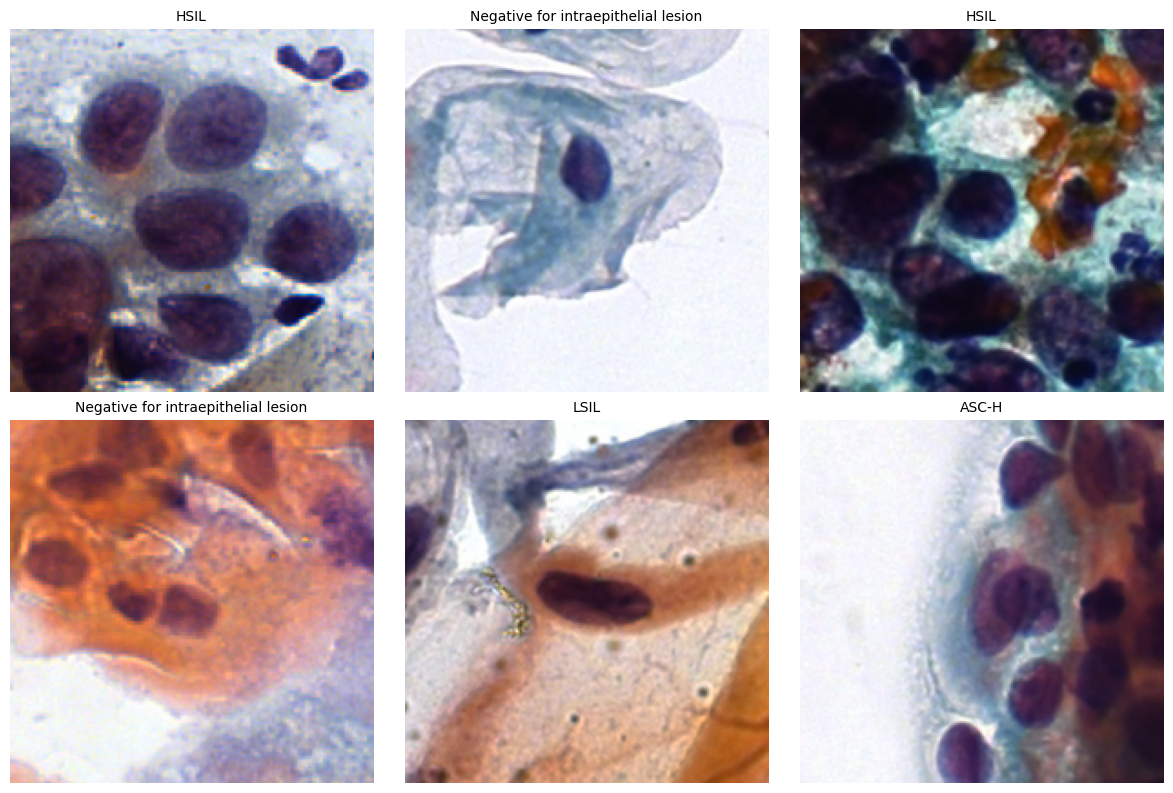

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

PREVIEW_CROP_SIZE = 200
half = PREVIEW_CROP_SIZE // 2

def figshare_id_from_doi(doi):
    return doi.rstrip("/").split("figshare.")[-1]

sample_rows = cric_df.sample(6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    fsid = figshare_id_from_doi(row["image_doi"])
    on_disk_name = f"{fsid}_{row['image_filename']}"
    img = Image.open(os.path.join(CRIC_IMAGES_DIR, on_disk_name)).convert("RGB")
    w, h = img.size
    cx, cy = int(row["nucleus_x"]), int(row["nucleus_y"])
    left = max(0, min(cx - half, w - PREVIEW_CROP_SIZE))
    top = max(0, min(cy - half, h - PREVIEW_CROP_SIZE))
    crop = img.crop((left, top, left + PREVIEW_CROP_SIZE, top + PREVIEW_CROP_SIZE))
    ax.imshow(crop)
    ax.set_title(row["bethesda_system"], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Preview crop locations on the full slide

This is the stronger version of the check above: it shows 3 whole field images with a red box drawn around every single cell that got labeled on that slide, plus a couple of the actual crops taken from it — confirming the coordinates line up with real cells and not empty background.

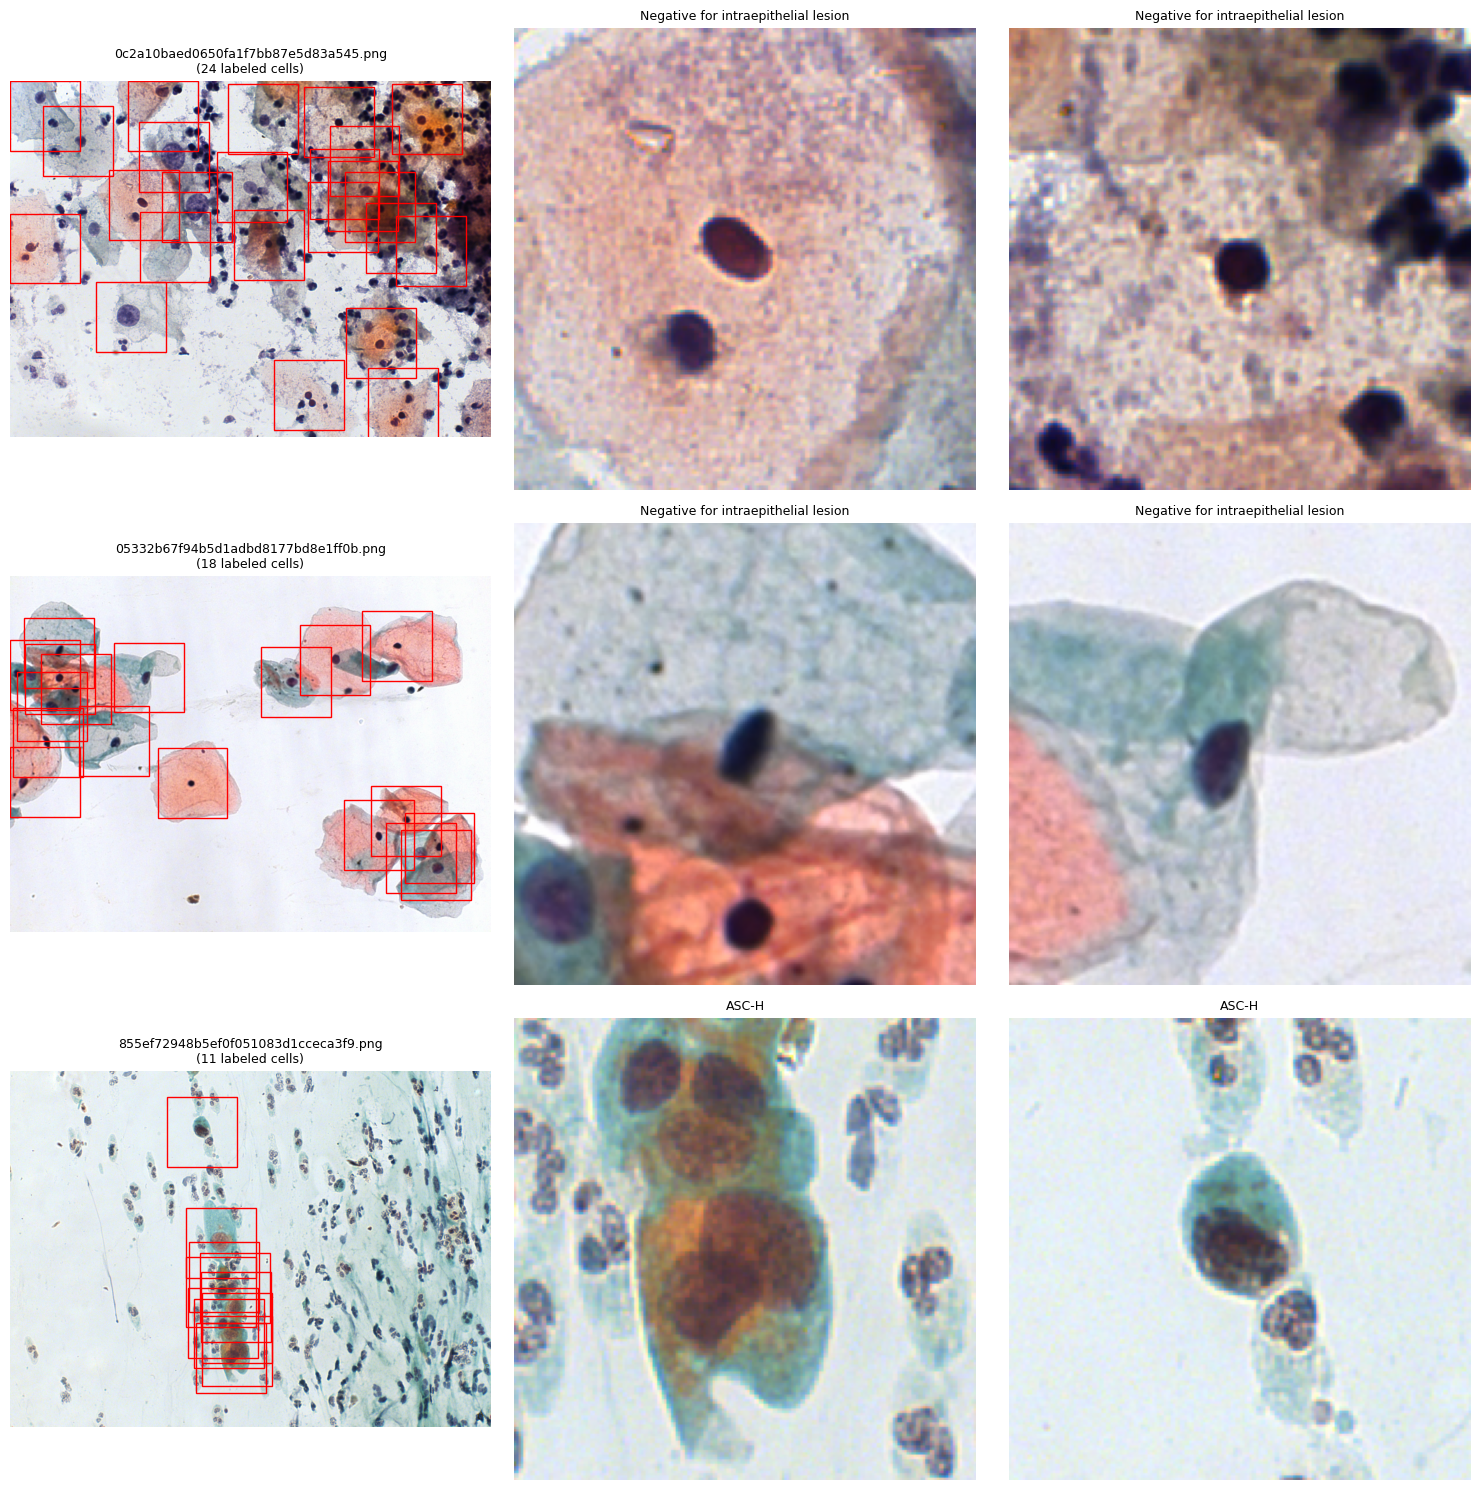

In [16]:
import random
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

CROP_SIZE = 200
half = CROP_SIZE // 2

def figshare_id_from_doi(doi):
    return doi.rstrip("/").split("figshare.")[-1]

slide_names = cric_df["image_filename"].unique()
chosen_slides = random.sample(list(slide_names), 3)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row_idx, slide in enumerate(chosen_slides):
    slide_rows = cric_df[cric_df["image_filename"] == slide]
    fsid = figshare_id_from_doi(slide_rows.iloc[0]["image_doi"])
    on_disk_name = f"{fsid}_{slide}"
    img = Image.open(os.path.join(CRIC_IMAGES_DIR, on_disk_name)).convert("RGB")
    w, h = img.size

    ax_full = axes[row_idx, 0]
    ax_full.imshow(img)
    for _, r in slide_rows.iterrows():
        cx, cy = int(r["nucleus_x"]), int(r["nucleus_y"])
        left = max(0, min(cx - half, w - CROP_SIZE))
        top = max(0, min(cy - half, h - CROP_SIZE))
        rect = patches.Rectangle((left, top), CROP_SIZE, CROP_SIZE, linewidth=1, edgecolor="red", facecolor="none")
        ax_full.add_patch(rect)
    ax_full.set_title(f"{slide}\n({len(slide_rows)} labeled cells)", fontsize=9)
    ax_full.axis("off")

    examples = slide_rows.sample(min(2, len(slide_rows)))
    for col_idx, (_, r) in enumerate(examples.iterrows(), start=1):
        cx, cy = int(r["nucleus_x"]), int(r["nucleus_y"])
        left = max(0, min(cx - half, w - CROP_SIZE))
        top = max(0, min(cy - half, h - CROP_SIZE))
        crop = img.crop((left, top, left + CROP_SIZE, top + CROP_SIZE))
        axes[row_idx, col_idx].imshow(crop)
        axes[row_idx, col_idx].set_title(r["bethesda_system"], fontsize=9)
        axes[row_idx, col_idx].axis("off")

plt.tight_layout()
plt.show()

## Crop all 11,534 CRIC cells

The real run: goes through every labeled cell in the CSV, cuts a 200x200 pixel square centered on its marked location out of its field image, and saves it into a folder named after its severity class — same "one folder per class" shape as SIPaKMeD and Mendeley. This is the step that turns CRIC into single-cell images the model can actually train on.

In [17]:
import os
from PIL import Image

CRIC_IMAGES_DIR = os.path.join(CRIC_ROOT, "images")
CRIC_CROPPED_OUTPUT = "/kaggle/working/CRIC_cropped"
CROP_SIZE = 200

def figshare_id_from_doi(doi):
    return doi.rstrip("/").split("figshare.")[-1]

os.makedirs(CRIC_CROPPED_OUTPUT, exist_ok=True)
for cls in cric_df["bethesda_system"].unique():
    os.makedirs(os.path.join(CRIC_CROPPED_OUTPUT, cls), exist_ok=True)

half = CROP_SIZE // 2
current_filename, current_image = None, None
n_ok, n_failed = 0, 0

for i, row in cric_df.iterrows():
    fsid = figshare_id_from_doi(row["image_doi"])
    on_disk_name = f"{fsid}_{row['image_filename']}"

    if on_disk_name != current_filename:
        try:
            current_image = Image.open(os.path.join(CRIC_IMAGES_DIR, on_disk_name)).convert("RGB")
            current_filename = on_disk_name
        except Exception as exc:
            print(f"  couldn't open {on_disk_name}: {exc}")
            n_failed += 1
            continue

    w, h = current_image.size
    cx, cy = int(row["nucleus_x"]), int(row["nucleus_y"])
    left = max(0, min(cx - half, w - CROP_SIZE))
    top = max(0, min(cy - half, h - CROP_SIZE))
    crop = current_image.crop((left, top, left + CROP_SIZE, top + CROP_SIZE))

    out_name = f"{row['image_id']}_{row['cell_id']}.png"
    out_path = os.path.join(CRIC_CROPPED_OUTPUT, row["bethesda_system"], out_name)
    crop.save(out_path)
    n_ok += 1

    if (i + 1) % 2000 == 0:
        print(f"  {i + 1}/{len(cric_df)} cells processed...")

print(f"\nDone: {n_ok} cells cropped, {n_failed} failed, saved into {CRIC_CROPPED_OUTPUT}")

  2000/11534 cells processed...
  4000/11534 cells processed...
  6000/11534 cells processed...
  8000/11534 cells processed...
  10000/11534 cells processed...

Done: 11534 cells cropped, 0 failed, saved into /kaggle/working/CRIC_cropped


## Check whether SIPaKMeD and Mendeley need slide-level splitting too

CRIC needs slide-level splitting because 11,534 cells come from only 400 slides. Before deciding how to split SIPaKMeD and Mendeley, this looks at a sample of their filenames to see if multiple crops share an obvious parent-image prefix (same risk as CRIC) or if each file looks independent.

In [7]:
print("SIPaKMeD example filenames:")
for m in sipakmed_matches[:1]:
    cropped_dir = os.path.join(m, "CROPPED")
    for f in sorted(os.listdir(cropped_dir))[:10]:
        print(" ", f)

print("\nMendeley example filenames:")
first_class = sorted(os.listdir(mendeley_root))[0]
cls_dir = os.path.join(mendeley_root, first_class)
for f in sorted(os.listdir(cls_dir))[:10]:
    print(" ", f)

SIPaKMeD example filenames:
  001_01.bmp
  001_01_cyt.dat
  001_01_nuc.dat
  001_02.bmp
  001_02_cyt.dat
  001_02_nuc.dat
  001_03.bmp
  001_03_cyt.dat
  001_03_nuc.dat
  001_04.bmp

Mendeley example filenames:
  HSIL_1 (1).jpg
  HSIL_1 (10).jpg
  HSIL_1 (11).jpg
  HSIL_1 (12).jpg
  HSIL_1 (13).jpg
  HSIL_1 (14).jpg
  HSIL_1 (15).jpg
  HSIL_1 (2).jpg
  HSIL_1 (3).jpg
  HSIL_1 (4).jpg


## Confirm SIPaKMeD and Mendeley also need photo-level splitting

Same risk as CRIC: SIPaKMeD's crops are numbered per original field image (`001_01`, `001_02`... all share field image `001`), and Mendeley's are numbered per original photo (`HSIL_1 (1)`, `HSIL_1 (2)`... all share photo `HSIL_1`). This counts how many unique source images each dataset actually has, and how many crops come from each one, before any splitting logic gets written.

In [8]:
import re
import pandas as pd

def sipakmed_group_id(fname):
    return fname.split("_")[0]

def mendeley_group_id(fname):
    return re.split(r"\s*\(", fname)[0].strip()

print("SIPaKMeD:")
for m in sipakmed_matches:
    cropped_dir = os.path.join(m, "CROPPED")
    bmp_files = [f for f in os.listdir(cropped_dir) if f.lower().endswith(".bmp")]
    groups = pd.Series([sipakmed_group_id(f) for f in bmp_files])
    counts = groups.value_counts()
    print(f"  {os.path.basename(m)}: {len(bmp_files)} images, {groups.nunique()} unique source images, "
          f"{counts.min()}-{counts.max()} crops per image (mean {counts.mean():.1f})")

print("\nMendeley:")
for cls in sorted(os.listdir(mendeley_root)):
    cls_dir = os.path.join(mendeley_root, cls)
    if not os.path.isdir(cls_dir):
        continue
    img_files = [f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    groups = pd.Series([mendeley_group_id(f) for f in img_files])
    counts = groups.value_counts()
    print(f"  {cls}: {len(img_files)} images, {groups.nunique()} unique source photos, "
          f"{counts.min()}-{counts.max()} crops per photo (mean {counts.mean():.1f})")

SIPaKMeD:
  im_Parabasal: 787 images, 108 unique source images, 1-26 crops per image (mean 7.3)
  im_Dyskeratotic: 813 images, 223 unique source images, 1-24 crops per image (mean 3.6)
  im_Metaplastic: 793 images, 271 unique source images, 1-15 crops per image (mean 2.9)
  im_Superficial-Intermediate: 831 images, 126 unique source images, 1-22 crops per image (mean 6.6)
  im_Koilocytotic: 825 images, 238 unique source images, 1-25 crops per image (mean 3.5)

Mendeley:
  High squamous intra-epithelial lesion: 163 images, 10 unique source photos, 5-28 crops per photo (mean 16.3)
  Low squamous intra-epithelial lesion: 113 images, 4 unique source photos, 21-37 crops per photo (mean 28.2)
  Negative for Intraepithelial malignancy: 612 images, 43 unique source photos, 2-25 crops per photo (mean 14.2)
  Squamous cell carcinoma: 74 images, 4 unique source photos, 11-27 crops per photo (mean 18.5)


## Build a manifest for each dataset, split by source image not by individual crop

This walks each dataset's folder, records every crop's file path, class, and which original source image it came from (the "group"), then splits so a whole group always lands together in train, val, or test, never divided across them. SIPaKMeD and Mendeley are split per class since each source photo only ever belongs to one class. CRIC is split as one pool of slides first, since a single CRIC field image can contain more than one class of cell — trying to stratify it by class first would contradict that.

In [5]:
import os
import re
import random
import pandas as pd

RANDOM_SEED = 42

# locate CRIC_cropped wherever it currently lives - this session's own /kaggle/working,
# or the published cervigrade-cric-dataset under /kaggle/input if attached fresh
cric_cropped_candidates = []
for root in ["/kaggle/working", "/kaggle/input"]:
    if not os.path.isdir(root):
        continue
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath) == "CRIC_cropped":
            cric_cropped_candidates.append(dirpath)
print("CRIC_cropped found at:", cric_cropped_candidates)
CRIC_CROPPED_DIR = cric_cropped_candidates[0]

def build_cric_manifest():
    rows = []
    for cls in sorted(os.listdir(CRIC_CROPPED_DIR)):
        cls_dir = os.path.join(CRIC_CROPPED_DIR, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            slide_id = fname.split("_")[0]
            rows.append({"filepath": os.path.join(cls_dir, fname), "label": cls,
                         "dataset": "CRIC", "group": f"CRIC_slide_{slide_id}"})
    return pd.DataFrame(rows)

def build_sipakmed_manifest():
    rows = []
    for m in sipakmed_matches:
        cls = os.path.basename(m)
        cropped_dir = os.path.join(m, "CROPPED")
        for fname in os.listdir(cropped_dir):
            if not fname.lower().endswith(".bmp"):
                continue
            field_id = fname.split("_")[0]
            rows.append({"filepath": os.path.join(cropped_dir, fname), "label": cls,
                         "dataset": "SIPaKMeD", "group": f"SIPaKMeD_{cls}_{field_id}"})
    return pd.DataFrame(rows)

def build_mendeley_manifest():
    rows = []
    for cls in sorted(os.listdir(mendeley_root)):
        cls_dir = os.path.join(mendeley_root, cls)
        if not os.path.isdir(cls_dir):
            continue
        for fname in os.listdir(cls_dir):
            if not fname.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            photo_id = re.split(r"\s*\(", fname)[0].strip()
            rows.append({"filepath": os.path.join(cls_dir, fname), "label": cls,
                         "dataset": "Mendeley", "group": f"Mendeley_{photo_id}"})
    return pd.DataFrame(rows)

cric_manifest = build_cric_manifest()
sipakmed_manifest = build_sipakmed_manifest()
mendeley_manifest = build_mendeley_manifest()

def allocate_group_counts(n, train_frac=0.7, val_frac=0.15, test_frac=0.15):
    if n == 1:
        return 1, 0, 0
    if n == 2:
        return 1, 0, 1
    n_test = max(1, round(n * test_frac))
    n_val = max(1, round(n * val_frac)) if n - n_test >= 2 else 0
    n_train = n - n_test - n_val
    if n_train < 1:
        n_train = 1
        if n_val > 0:
            n_val -= 1
        else:
            n_test -= 1
    return n_train, n_val, n_test

def split_by_group_per_class(manifest_df, seed=RANDOM_SEED):
    rng = random.Random(seed)
    group_split = {}
    for label, sub in manifest_df.groupby("label"):
        groups = sorted(sub["group"].unique())
        rng.shuffle(groups)
        n_train, n_val, n_test = allocate_group_counts(len(groups))
        for g in groups[:n_train]:
            group_split[g] = "train"
        for g in groups[n_train:n_train + n_val]:
            group_split[g] = "val"
        for g in groups[n_train + n_val:n_train + n_val + n_test]:
            group_split[g] = "test"
    return manifest_df["group"].map(group_split)

def split_by_group_global(manifest_df, seed=RANDOM_SEED, train_frac=0.7, val_frac=0.15):
    rng = random.Random(seed)
    groups = sorted(manifest_df["group"].unique())
    rng.shuffle(groups)
    n = len(groups)
    n_train = round(n * train_frac)
    n_val = round(n * val_frac)
    group_split = {}
    for g in groups[:n_train]:
        group_split[g] = "train"
    for g in groups[n_train:n_train + n_val]:
        group_split[g] = "val"
    for g in groups[n_train + n_val:]:
        group_split[g] = "test"
    return manifest_df["group"].map(group_split)

cric_manifest["split"] = split_by_group_global(cric_manifest)
sipakmed_manifest["split"] = split_by_group_per_class(sipakmed_manifest)
mendeley_manifest["split"] = split_by_group_per_class(mendeley_manifest)

for name, df in [("CRIC", cric_manifest), ("SIPaKMeD", sipakmed_manifest), ("Mendeley", mendeley_manifest)]:
    print(f"\n{name}:")
    table = df.groupby(["label", "split"]).size().unstack(fill_value=0)
    print(table)
    for label in table.index:
        if table.loc[label].get("test", 0) == 0:
            print(f"  WARNING: '{label}' has 0 test images")
        if table.loc[label].get("val", 0) == 0:
            print(f"  note: '{label}' has 0 val images (too few source photos to spare one)")

CRIC_cropped found at: ['/kaggle/input/datasets/wagnermushayija/cervigrade-cric-dataset/CRIC_cropped']

CRIC:
split                                test  train  val
label                                                
ASC-H                                  49    651  225
ASC-US                                108    425   73
HSIL                                  418    906  379
LSIL                                  129   1079  152
Negative for intraepithelial lesion   985   4839  955
SCC                                    34    104   23

SIPaKMeD:
split                        test  train  val
label                                        
im_Dyskeratotic               139    566  108
im_Koilocytotic               138    570  117
im_Metaplastic                110    551  132
im_Parabasal                   98    558  131
im_Superficial-Intermediate   123    598  110

Mendeley:
split                                    test  train  val
label                                                   

## Save the manifests so future sessions don't need to rebuild the split

These three CSVs are the actual train/val/test assignment for every image — what the training notebook will load directly instead of rebuilding this logic each time. Since the split uses a fixed random seed, rerunning the cell above would always reproduce the exact same result anyway; this is mainly for convenience and as a fixed record of the exact split used.

In [6]:
cric_manifest.to_csv("/kaggle/working/cric_manifest.csv", index=False)
sipakmed_manifest.to_csv("/kaggle/working/sipakmed_manifest.csv", index=False)
mendeley_manifest.to_csv("/kaggle/working/mendeley_manifest.csv", index=False)

print("Saved:")
for name, df in [("cric_manifest.csv", cric_manifest), ("sipakmed_manifest.csv", sipakmed_manifest), ("mendeley_manifest.csv", mendeley_manifest)]:
    print(f"  {name}: {len(df)} rows")

Saved:
  cric_manifest.csv: 11534 rows
  sipakmed_manifest.csv: 4049 rows
  mendeley_manifest.csv: 962 rows


## Phase 1 complete: dataset acquisition, cropping, and splitting

**What this notebook did:**
- Attached SIPaKMeD and Mendeley LBC as existing Kaggle datasets (both already single-cell images, no cropping needed).
- Downloaded CRIC directly from Figshare (no Kaggle mirror exists for it), and checked its label file and on-disk filename pattern before writing any cropping code.
- Cropped all 11,534 labeled CRIC cells into single 200x200 images centered on each cell's nucleus, one folder per Bethesda class, then published the result as its own Kaggle dataset (`cervigrade-cric-dataset`) so future notebooks attach it directly instead of re-downloading or re-cropping.
- Found that SIPaKMeD's and Mendeley's crops are also grouped by original source image (several cells cropped from the same field image or photo), the same leakage risk CRIC has, and built a train/val/test split for all three datasets that keeps every crop from one source image on the same side of the split.

**Final split sizes (train / val / test):**

CRIC:
- ASC-H: 651 / 225 / 49
- ASC-US: 425 / 73 / 108
- HSIL: 906 / 379 / 418
- LSIL: 1079 / 152 / 129
- Negative for intraepithelial lesion: 4839 / 955 / 985
- SCC: 104 / 23 / 34

SIPaKMeD:
- Dyskeratotic: 566 / 108 / 139
- Koilocytotic: 570 / 117 / 138
- Metaplastic: 551 / 132 / 110
- Parabasal: 558 / 131 / 98
- Superficial-Intermediate: 598 / 110 / 123

Mendeley LBC:
- HSIL: 105 / 24 / 34
- LSIL: 49 / 27 / 37
- Negative: 428 / 99 / 85
- SCC: 26 / 27 / 21

**Known limitation:** Mendeley's LSIL and SCC classes come from only 4 original source photos each, so their test-set results reflect very few distinct patients and should be read with caution, not as strong evidence either way. This is a property of the dataset itself, not something the split logic can fix, and is worth a line in the paper's limitations section. Also worth a quick double-check later: the manifest found 962 Mendeley images rather than the documented 963 — likely one non-image or duplicate file, not investigated further here.

**Not done in this notebook:** no model training has started. This covers acquisition and preprocessing only (Phase 1).

**Next steps (Phase 2, a separate training notebook):**
1. Start a new Kaggle notebook with the GPU accelerator on, and attach SIPaKMeD, Mendeley, and `cervigrade-cric-dataset` as inputs.
2. Re-run the manifest-building and split cells there (fast, no downloading needed), or load the three saved CSVs directly.
3. Fine-tune EfficientNetB0, ConvNeXt, and RegNet on SIPaKMeD's 5-class cell-type task first, starting from ImageNet weights, and save each resulting checkpoint.
4. From those checkpoints, fine-tune each of the three architectures separately on CRIC and on Mendeley for severity grading (6 runs total).
5. Run PLIP's frozen encoder over CRIC and Mendeley to extract features, and train a lightweight classifier on top of each (linear probing, 2 runs).
6. Evaluate all 8 runs with weighted F1-score (primary), per-class sensitivity for the most severe grade, accuracy, and AUC, per the proposal's Chapter 3 metrics.
